In [20]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv ( "C:/users/hp/downloads/diabetes_risk_prediction_dataset.csv")
df.head(5)

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


## Handling missing values

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    500

In [22]:
df.isna().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [23]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [24]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

missing_df[missing_df['Missing %'] > 0]

,Missing Count,Missing %
Weight_kg,2962,5.924
Height_cm,2945,5.890
Sleep_Hours,2017,4.034
Exercise_Hours_Per_Week,1992,3.984
HbA1c,1974,3.948
Daily_Walking_Minutes,1964,3.928
HDL,1000,2.000
Total_Cholesterol,1000,2.000
Medication_Adherence,1000,2.000
LDL,1000,2.000


In [25]:
numeric = df.select_dtypes(include=['int64', 'float64'])
numeric.head()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
0,1,32.0,182.1,65.8,19.8,71.2,88.4,10.4,149.5,27.4,...,138.7,40.1,152.3,250.8,119,2.2,106.1,7.9,4.4,60
1,2,42.0,148.5,101.2,45.9,121.8,247.3,11.3,199.3,18.3,...,286.8,35.6,110.4,287.9,59,6.3,96.1,6.2,2.1,99
2,3,89.0,158.1,NaN,37.9,131.8,141.9,6.3,219.6,23.9,...,129.4,32.1,156.7,329.3,104,0.6,68.7,4.8,2.8,80
3,4,87.0,190.9,95.9,26.3,99.1,90.1,7.4,217.7,36.7,...,168.2,61.9,63.4,308.8,58,7.7,23.1,4.2,1.5,82
4,5,27.0,156.9,101.9,41.4,77.1,93.8,12.0,153.5,22.3,...,281.5,37.4,66.5,206.6,104,4.7,131.2,9.9,1.6,93


In [34]:
numeric.isna().sum()

Patient_ID                     0
Age                          497
Height_cm                   2945
Weight_kg                   2962
BMI                            0
Waist_Circumference_cm         0
Blood_Glucose                959
HbA1c                       1974
Fasting_Blood_Sugar            0
Insulin_Level                  0
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Total_Cholesterol           1000
HDL                         1000
LDL                         1000
Triglycerides               1000
Heart_Rate                     0
Exercise_Hours_Per_Week     1992
Daily_Walking_Minutes       1964
Sleep_Hours                 2017
Daily_Water_Intake_L           0
Diabetes_Risk_Score            0
dtype: int64

In [26]:
category = df.select_dtypes(include=['object', 'category'])
category.head()

,Gender,Country,Physical_Activity_Level,Diet_Quality,Sugar_Intake_Level,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,Male,Mexico,Moderate,Healthy,Low,Moderate,Former,Never,Yes,No,Yes,Yes,No,Good,Retired,Rural,Healthy Diet Plan,Yes,Moderate
1,Other,Saudi Arabia,High,Healthy,Low,Moderate,Current,Frequently,Yes,No,Yes,Yes,Yes,Average,Government,Rural,Begin Diabetes Management Plan,Yes,High
2,Other,Argentina,High,Average,High,High,Never,Frequently,Yes,No,No,Yes,No,Average,Government,Urban,Strict Blood Sugar Monitoring,Yes,High
3,Other,United States,High,Average,High,High,Current,Occasionally,Yes,Yes,No,No,No,Average,Business,Rural,Begin Diabetes Management Plan,Yes,High
4,Other,Australia,Moderate,Poor,High,Low,Never,Occasionally,No,Yes,Yes,Yes,Yes,Poor,Private,Rural,Begin Diabetes Management Plan,Yes,High


In [27]:
category.isna().sum()

Gender                           0
Country                          0
Physical_Activity_Level        500
Diet_Quality                     0
Sugar_Intake_Level               0
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabetes          0
Hypertension                     0
Heart_Disease                    0
Fatty_Liver                      0
PCOS                             0
Medication_Adherence          1000
Work_Type                        0
Residence_Type                   0
AI_Health_Recommendation         0
Doctor_Consultation_Needed       0
Diabetes_Risk                    0
dtype: int64

In [28]:
category.describe()

,Gender,Country,Physical_Activity_Level,Diet_Quality,Sugar_Intake_Level,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
count,50000,50000,49500,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,49000,50000,50000,50000,50000,50000
unique,3,25,3,3,3,3,3,3,2,2,2,2,2,3,5,2,15,2,3
top,Male,Malaysia,Low,Healthy,Low,Low,Former,Never,No,Yes,No,No,No,Good,Business,Urban,Strict Blood Sugar Monitoring,Yes,High
freq,16718,2083,16693,16882,16864,16725,16729,16712,25076,25200,25288,25155,25071,16361,10167,25129,7481,46426,36593


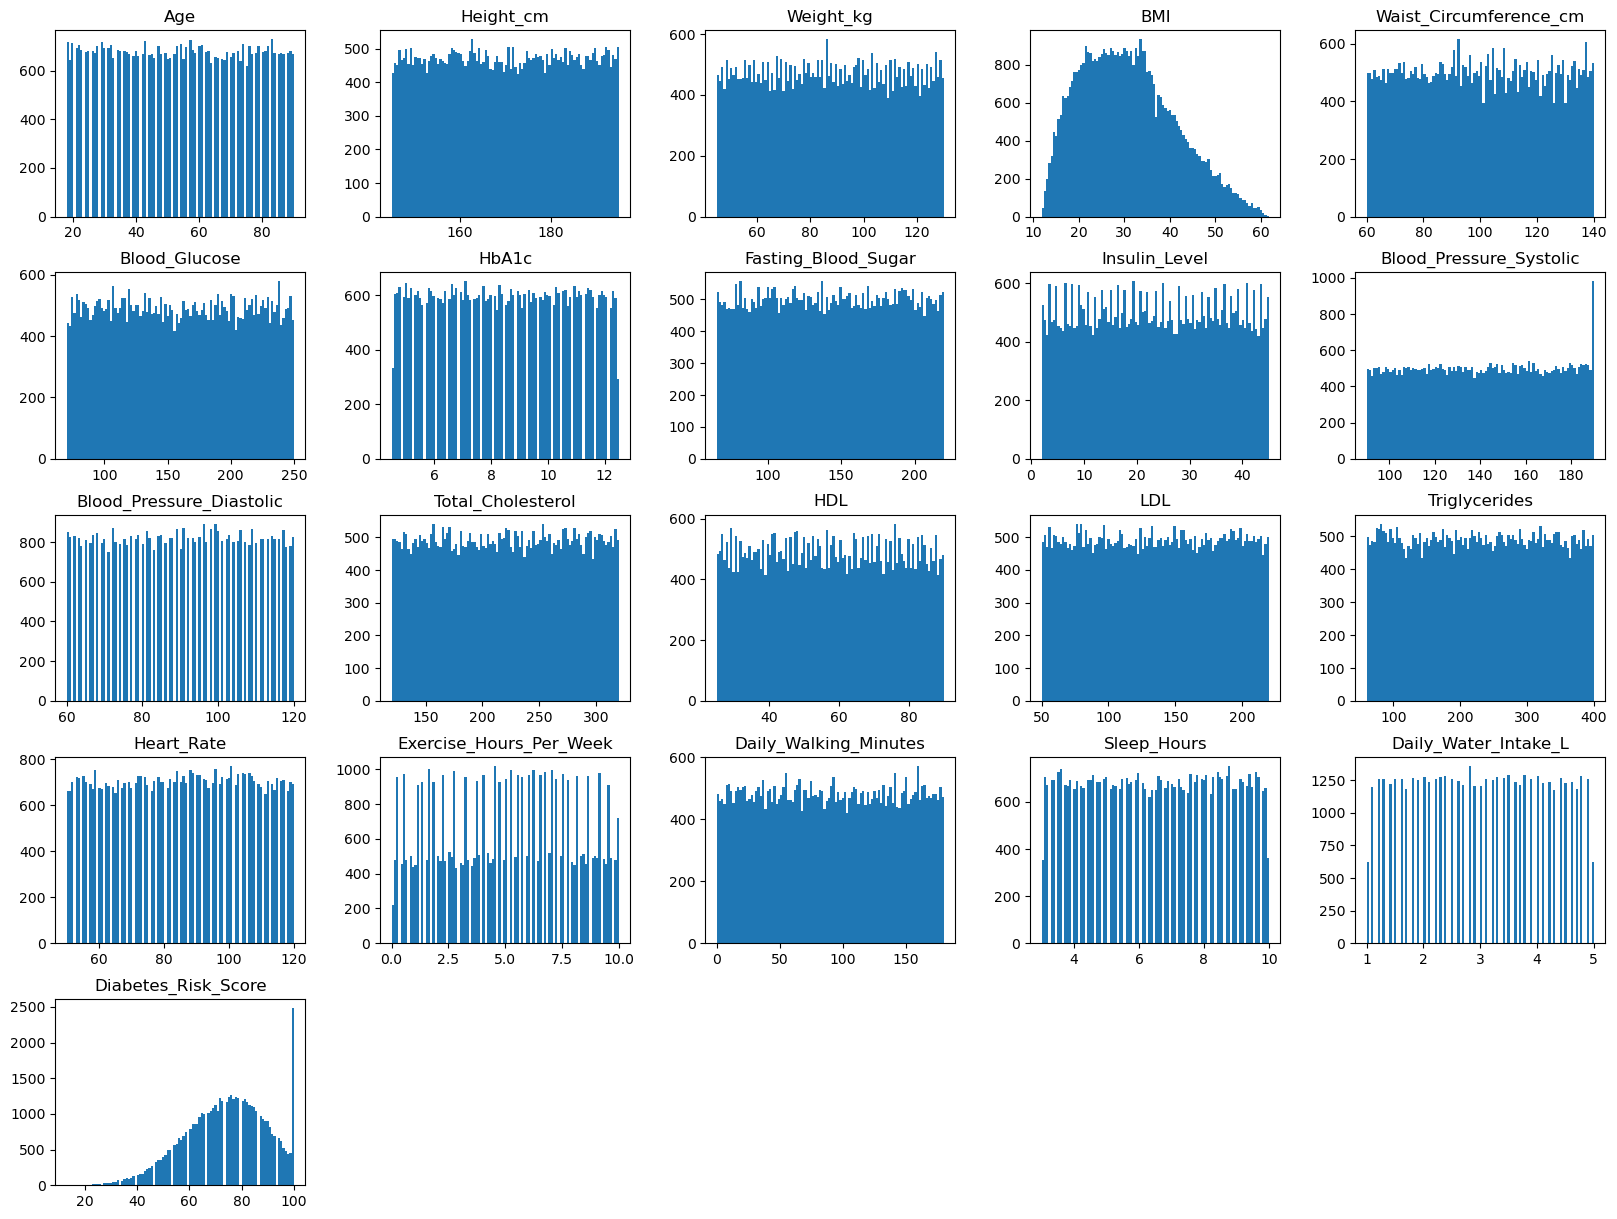

In [33]:
numeric.drop(columns = 'Patient_ID').hist( grid = False , figsize = (20,15) , bins = 100 )
plt.show()

In [49]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
category_cols = df.select_dtypes(include=['category', 'object']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

for col in category_cols:
    mode_val = df[col].mode()[0] 
    df[col] = df[col].fillna(mode_val)


In [52]:
df = df.drop( columns = ['Height_cm' ,'Weight_kg' ]) 
df.describe()

,Patient_ID,Age,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000
mean,25000.500000,53.87238,30.924056,99.960790,159.905144,8.488532,142.607294,23.476724,140.171120,90.039000,220.173262,57.370296,135.016234,229.542394,85.124260,5.016764,89.92820,6.50088,2.998842,74.043920
std,14433.901067,21.02487,10.290091,23.086579,51.539079,2.267625,44.681799,12.403841,29.168623,17.575503,57.212768,18.532543,48.641767,97.247581,20.390334,2.818052,51.00243,1.98647,1.152273,15.598327
min,1.000000,18.00000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,90.000000,60.000000,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.00000,3.00000,1.000000,13.000000
25%,12500.750000,36.00000,22.700000,80.000000,115.500000,6.600000,103.900000,12.800000,115.000000,75.000000,170.775000,41.600000,93.300000,146.400000,68.000000,2.600000,46.80000,4.80000,2.000000,64.000000
50%,25000.500000,54.00000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,140.000000,90.000000,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.80000,6.50000,3.000000,75.000000
75%,37500.250000,72.00000,37.800000,119.900000,204.200000,10.400000,181.500000,34.300000,165.000000,105.000000,269.500000,73.200000,176.900000,312.900000,103.000000,7.400000,133.40000,8.20000,4.000000,86.000000
max,50000.000000,90.00000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,190.000000,120.000000,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.00000,10.00000,5.000000,100.000000


In [53]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
category_cols = df.select_dtypes(include=['category', 'object']).columns

df[category_cols].describe()

,Gender,Country,Physical_Activity_Level,Diet_Quality,Sugar_Intake_Level,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,3,25,3,3,3,3,3,3,2,2,2,2,2,3,5,2,15,2,3
top,Male,Malaysia,Low,Healthy,Low,Low,Former,Never,No,Yes,No,No,No,Good,Business,Urban,Strict Blood Sugar Monitoring,Yes,High
freq,16718,2083,17193,16882,16864,16725,16729,16712,25076,25200,25288,25155,25071,17361,10167,25129,7481,46426,36593


## Data Analysis and insights

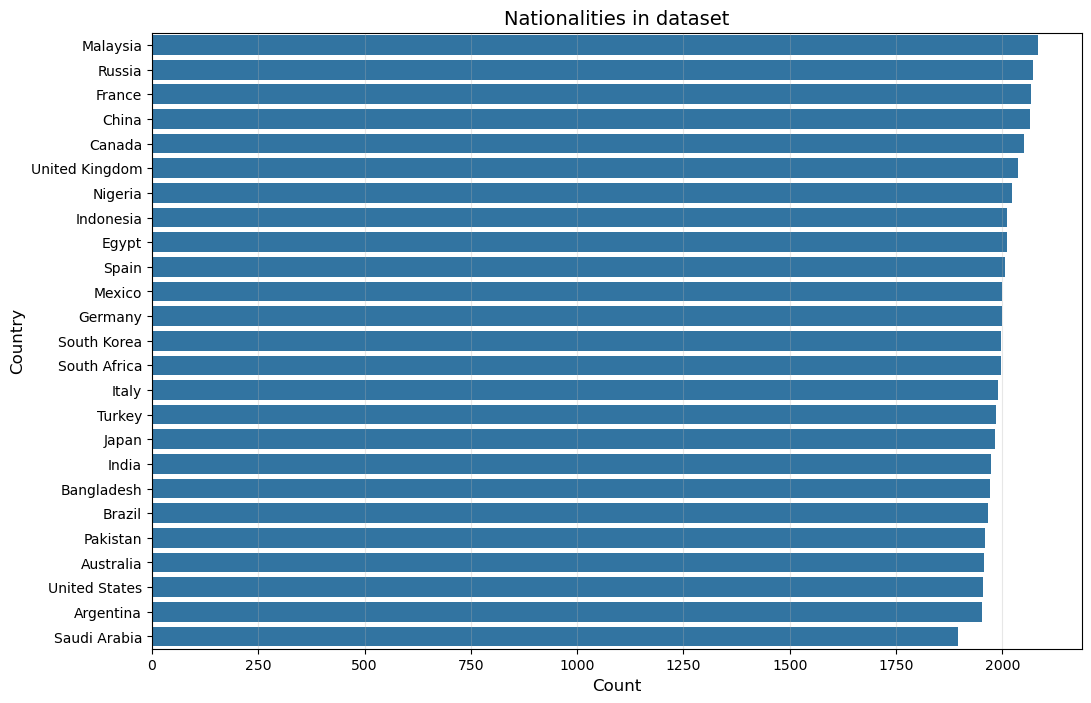

In [75]:
plt.figure(figsize=(12, 8))

country_order_asc = df['Country'].value_counts().sort_values(ascending=False).index

sns.countplot(
    data=df,
    y='Country',               
    order=country_order_asc         
)

plt.title('Nationalities in dataset', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

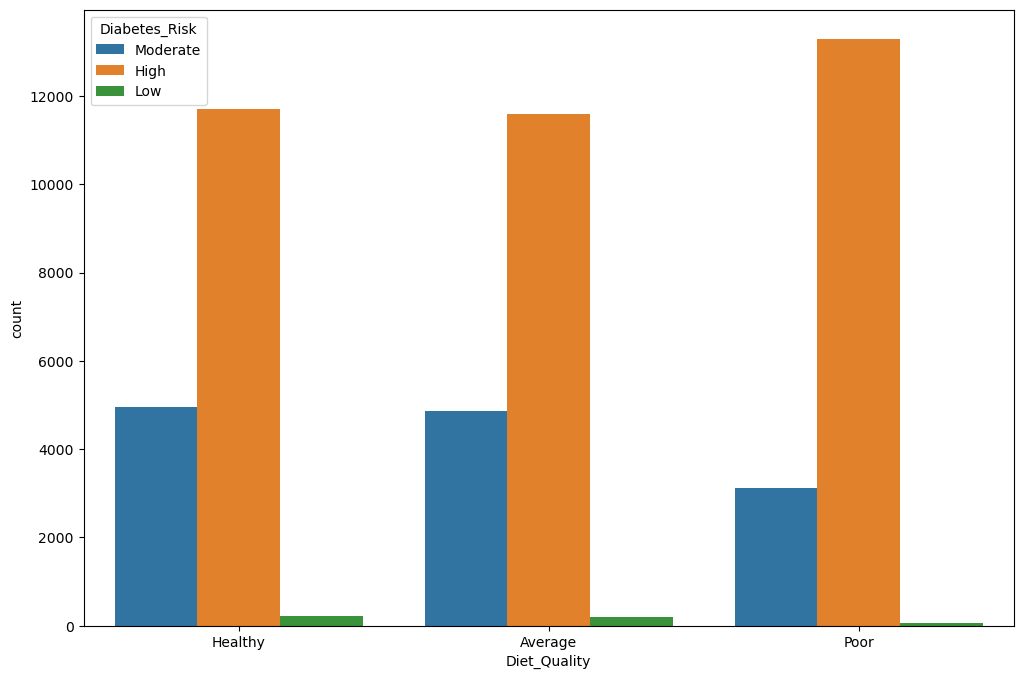

In [80]:
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df,
    x='Diet_Quality' ,
    hue = 'Diabetes_Risk' 
)

plt.show()

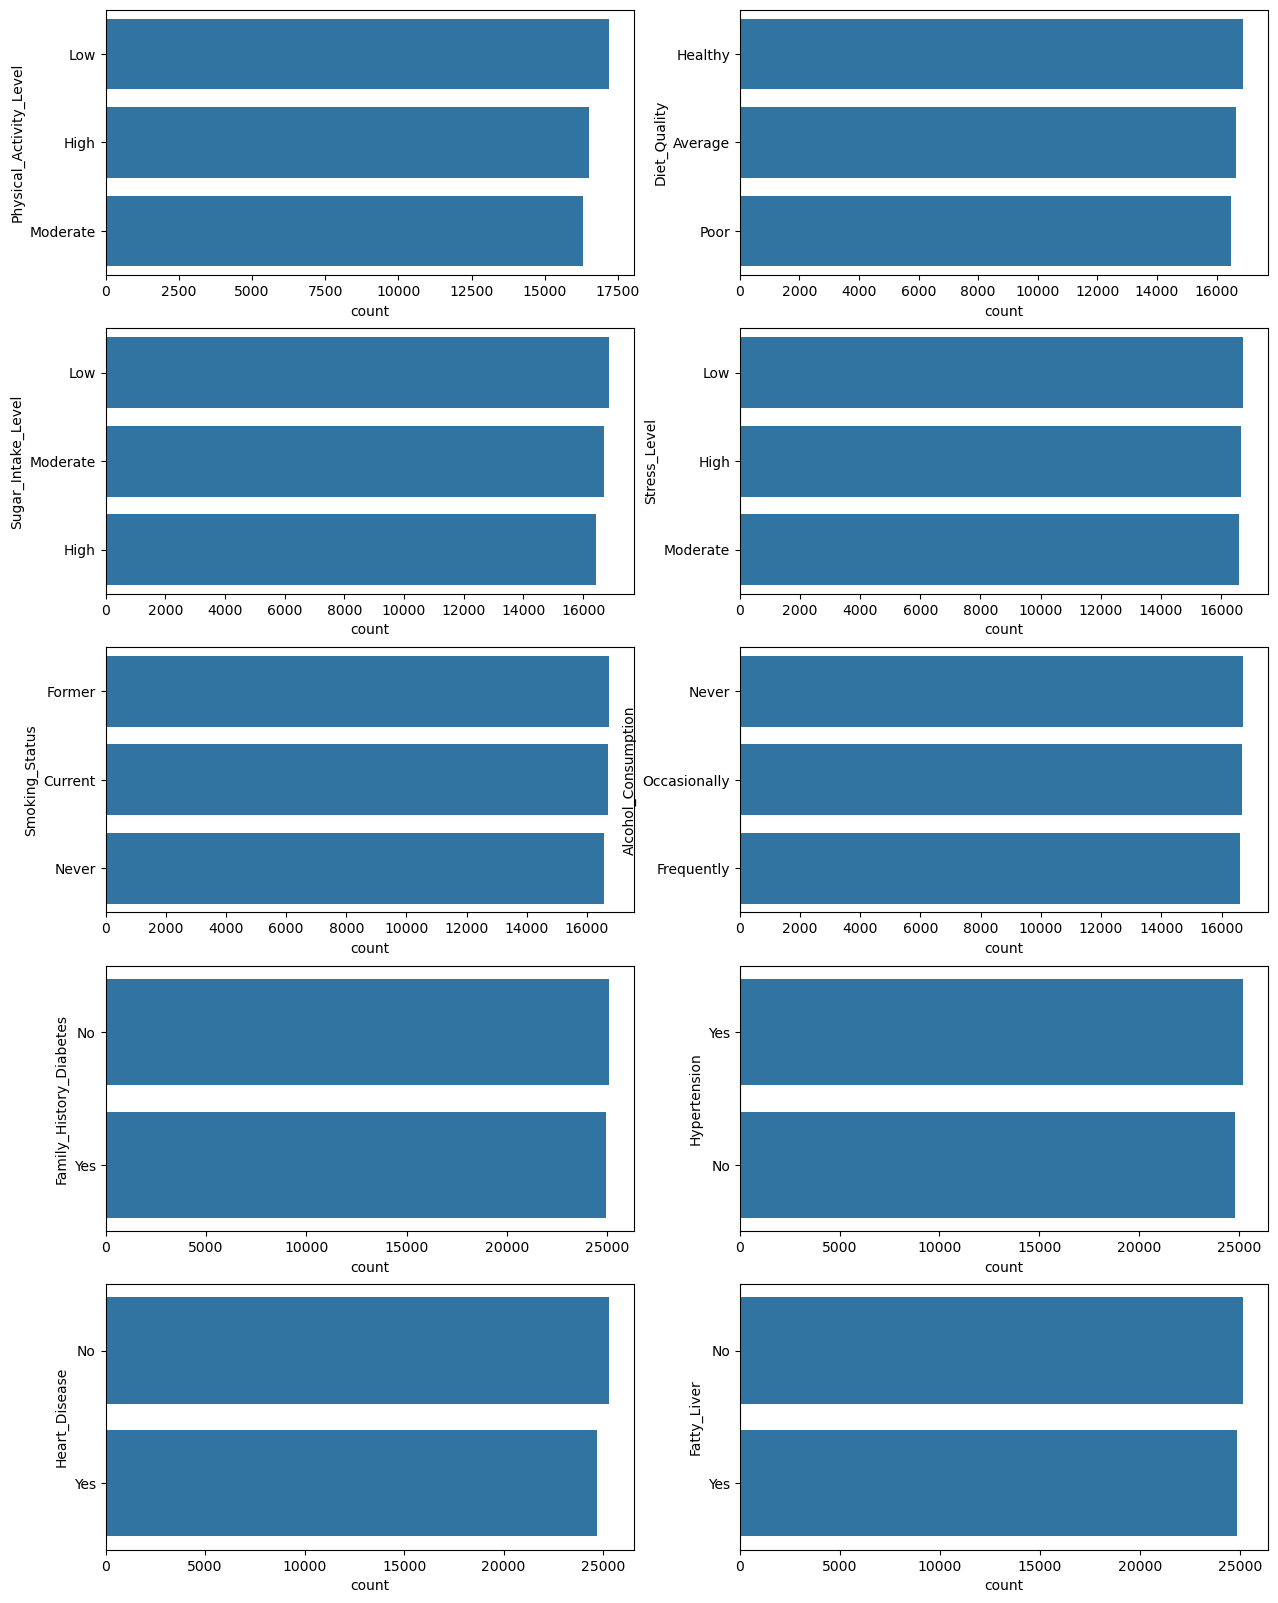

In [98]:
val = category_cols[2:12]


fig , ax  = plt.subplots( 5,2 , figsize = ( 15,20 ) )
ax = ax.flatten()

for idx , var in enumerate ( val ) : 
    order = df[var].value_counts().sort_values(ascending=False).index
    sns.countplot( data = df ,
                   y = var ,
                   order = order, 
                   ax = ax[idx]
                 )

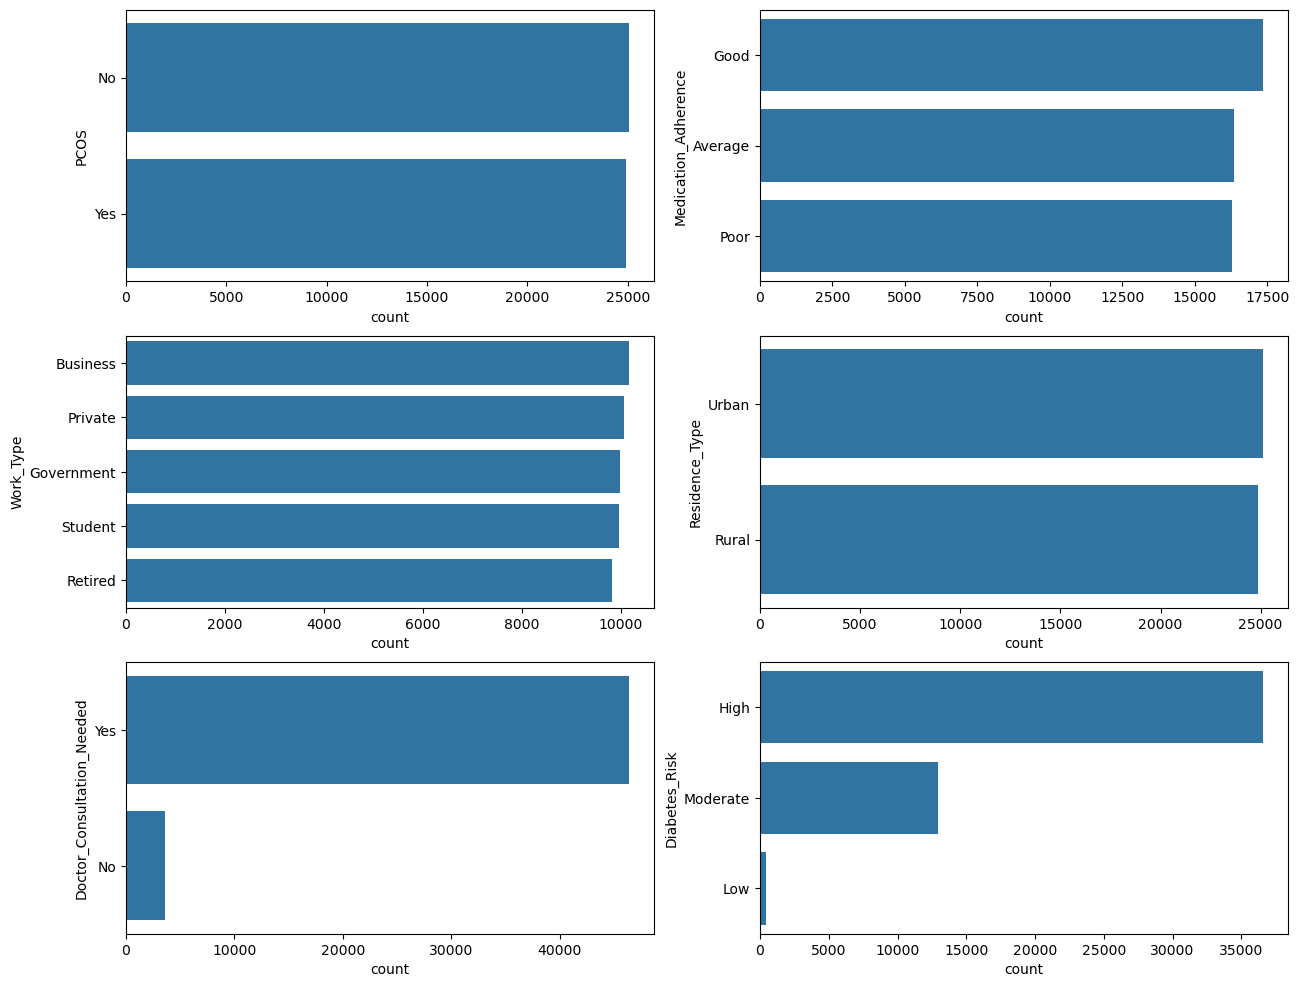

In [109]:
val =['PCOS', 'Medication_Adherence', 'Work_Type', 
      'Residence_Type',
      'Doctor_Consultation_Needed',
      'Diabetes_Risk']


fig , ax  = plt.subplots( 3,2 , figsize = ( 15,12 ) )
ax = ax.flatten()

for idx , var in enumerate ( val ) : 
    order = df[var].value_counts().sort_values(ascending=False).index
    sns.countplot( data = df ,
                   y = var ,
                   order = order, 
                   ax = ax[idx]
                 )

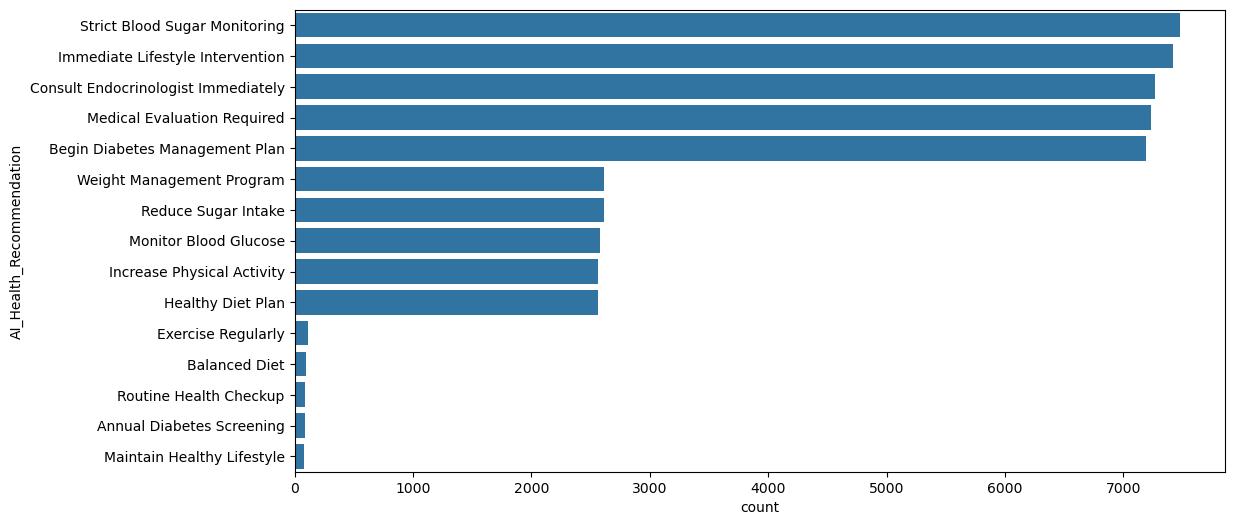

In [117]:
plt.figure(figsize = (12,6) )
sns.countplot ( data = df, y='AI_Health_Recommendation',
                order = df['AI_Health_Recommendation'].value_counts().sort_values(ascending=False).index 
              )
plt.show()

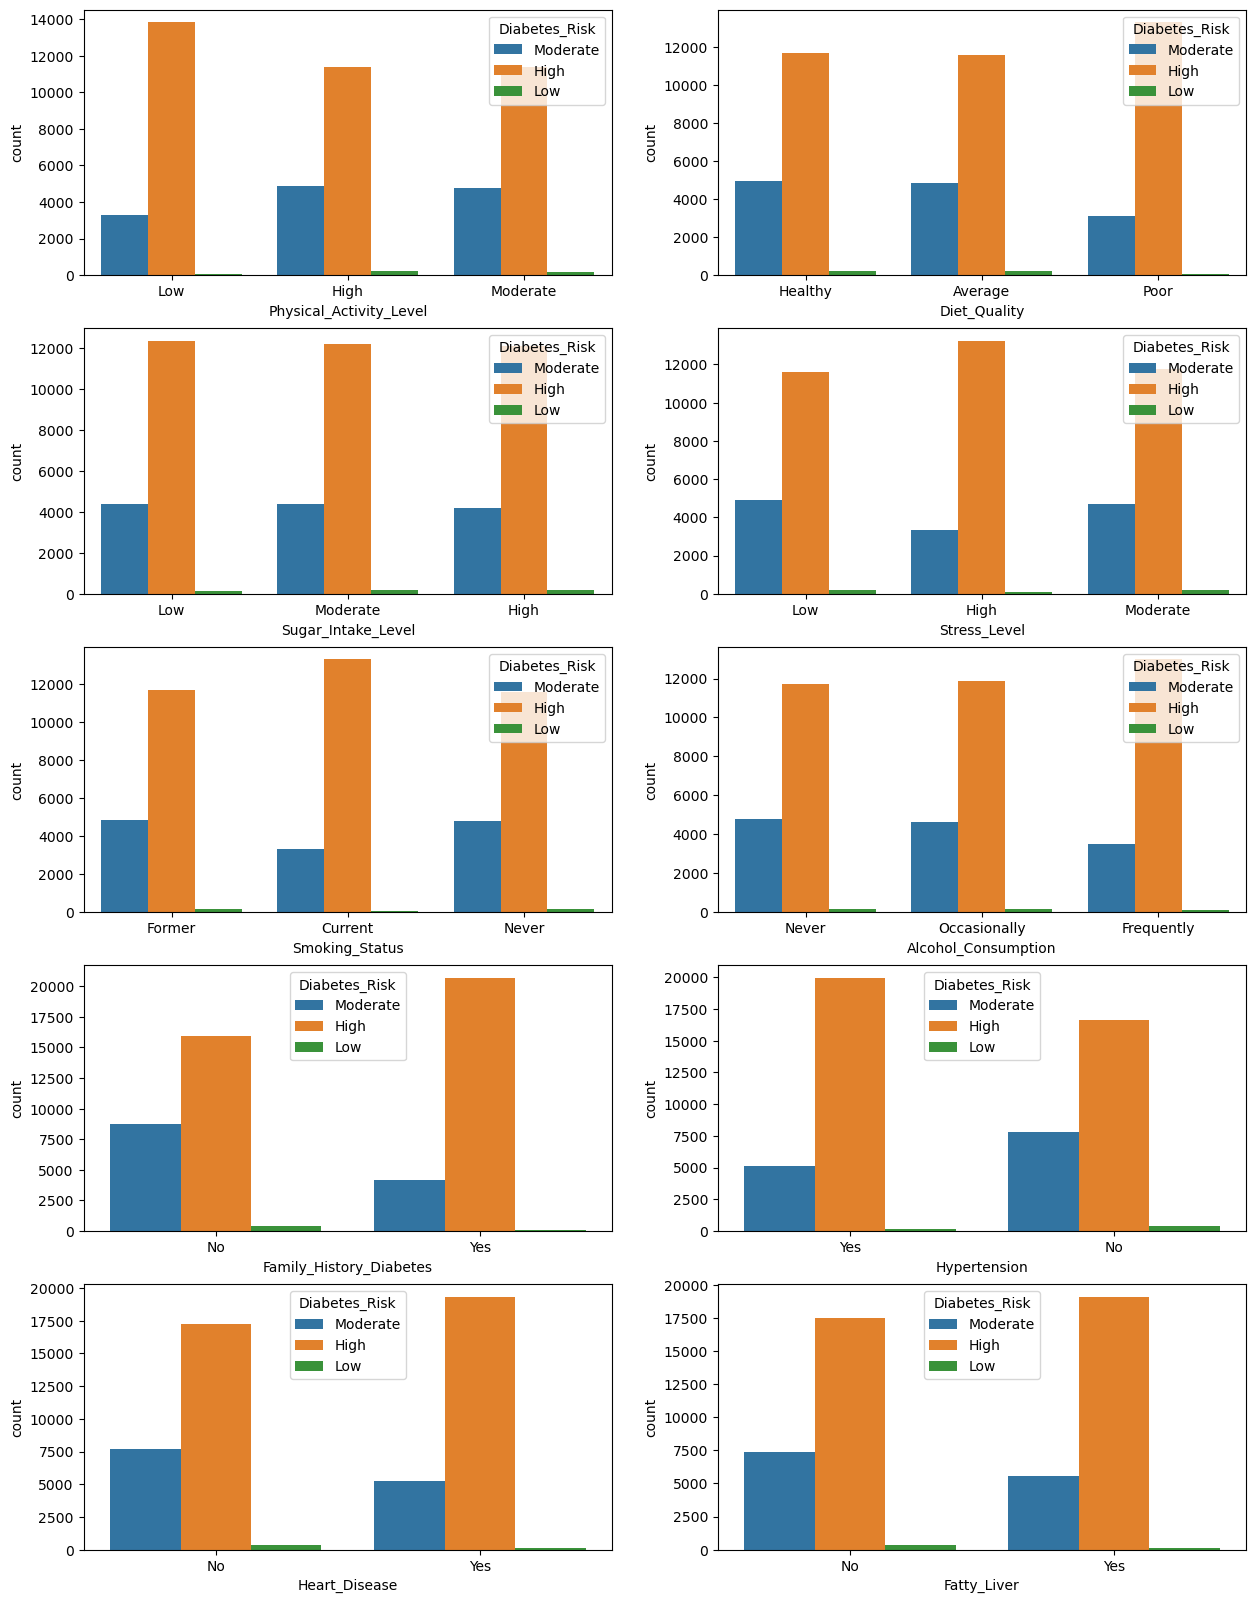

In [125]:
val = category_cols[2:12]


fig , ax  = plt.subplots( 5,2 , figsize = ( 15,20 ) )
ax = ax.flatten()

for idx , var in enumerate ( val ) : 
    order = df[var].value_counts().sort_values(ascending=False).index
    sns.countplot( data = df ,
                   x = var ,
                   hue = 'Diabetes_Risk',
                   order = order, 
                   ax = ax[idx]
                 )

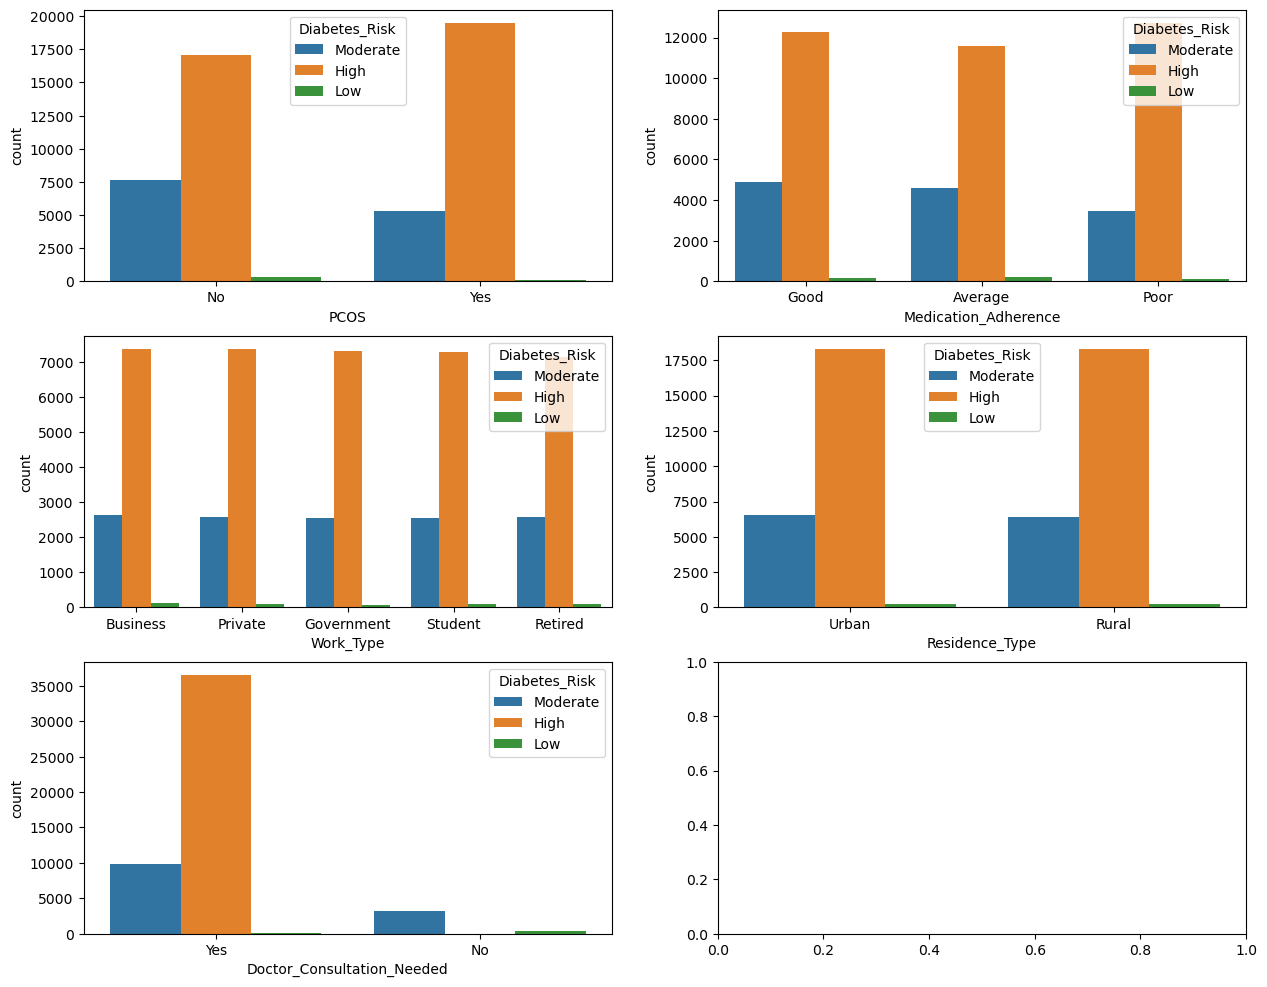

In [124]:
val =['PCOS', 'Medication_Adherence', 'Work_Type', 
      'Residence_Type',
      'Doctor_Consultation_Needed']


fig , ax  = plt.subplots( 3,2 , figsize = ( 15,12 ) )
ax = ax.flatten()

for idx , var in enumerate ( val ) : 
    order = df[var].value_counts().sort_values(ascending=False).index
    sns.countplot( data = df ,
                   x= var ,
                   order = order,
                   hue = 'Diabetes_Risk' ,
                   ax = ax[idx]
                 )

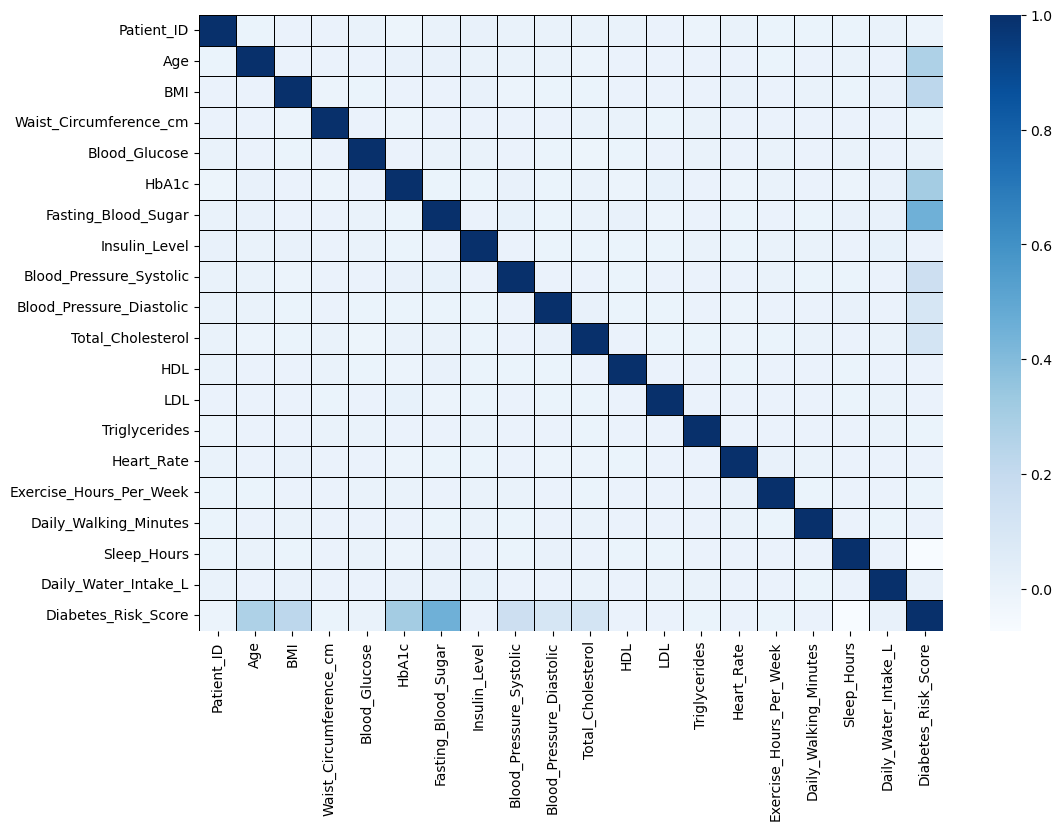

In [130]:
corr = df[numeric_cols].corr()
plt.figure( figsize = (12,8))
sns.heatmap( corr , cmap = 'Blues' , linewidths = 0.5 , linecolor= 'black' ) 
plt.xticks(rotation = 90 )
plt.show()

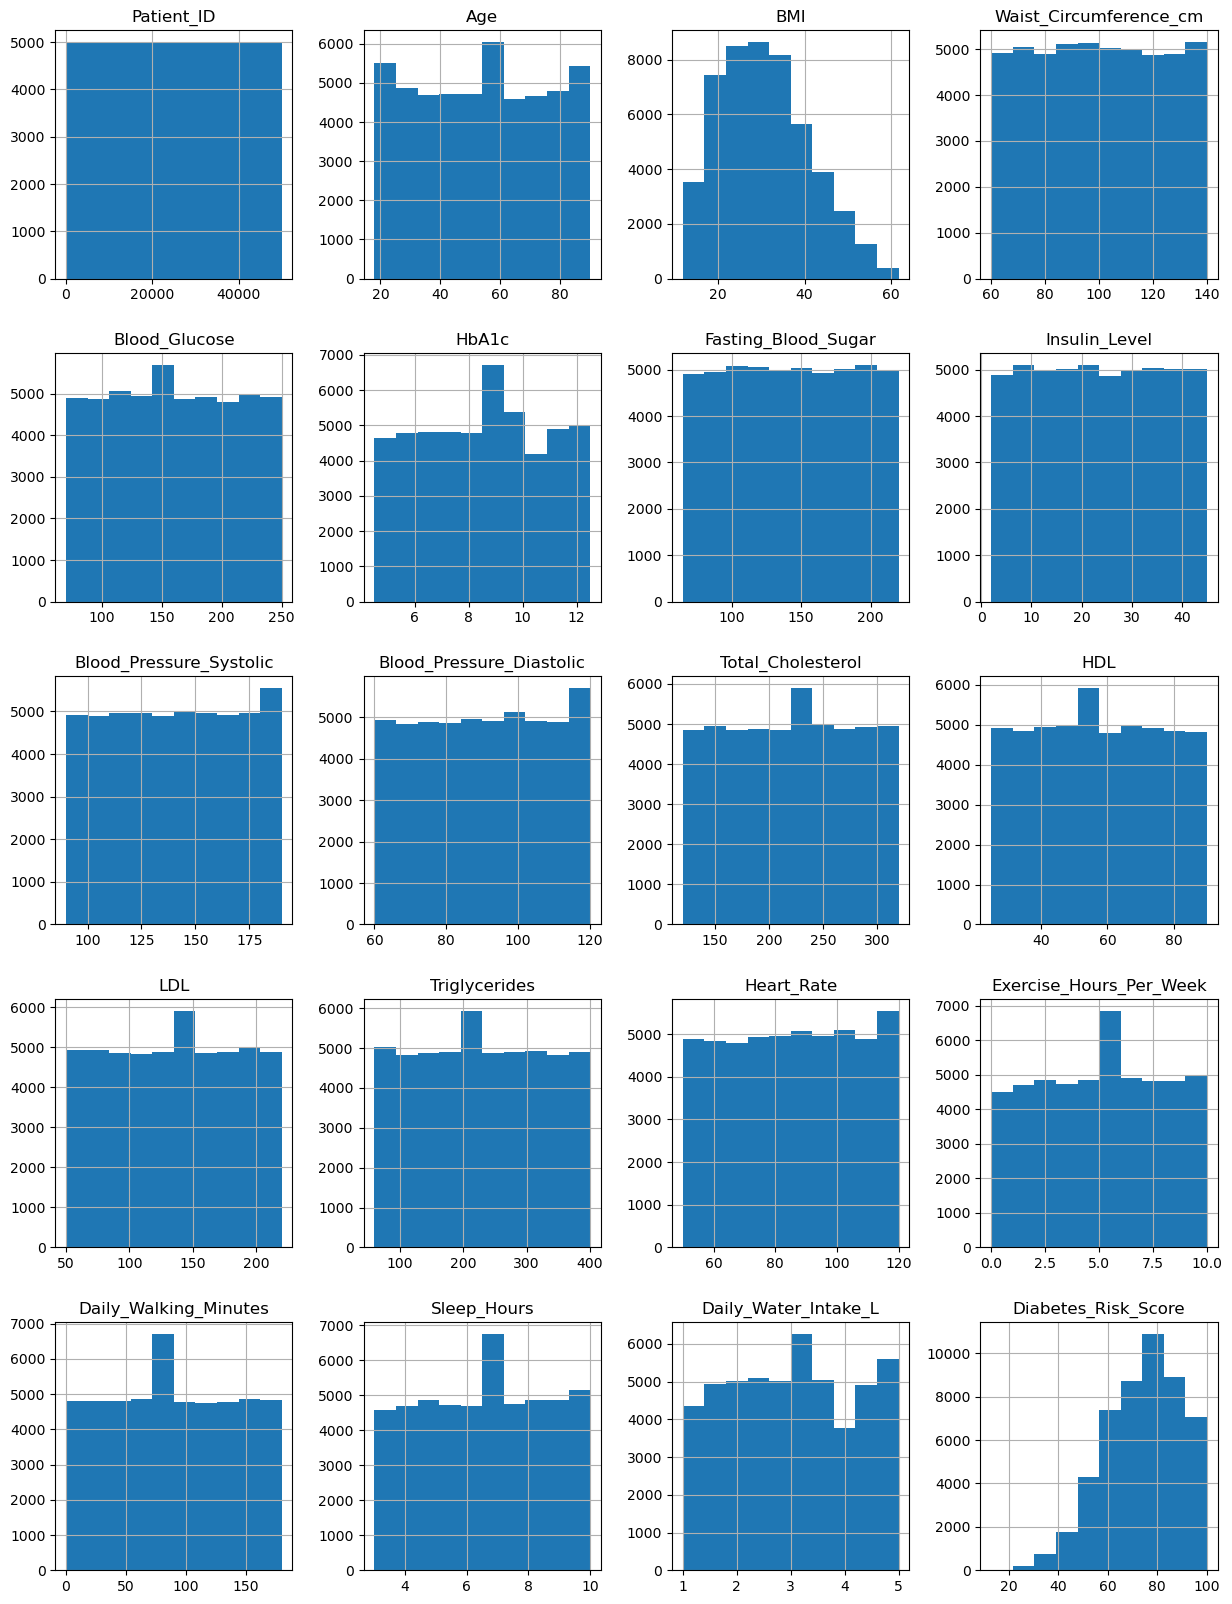

In [132]:
df[numeric_cols].hist( figsize = (15,20))

plt.show()

Very Random Dataset 

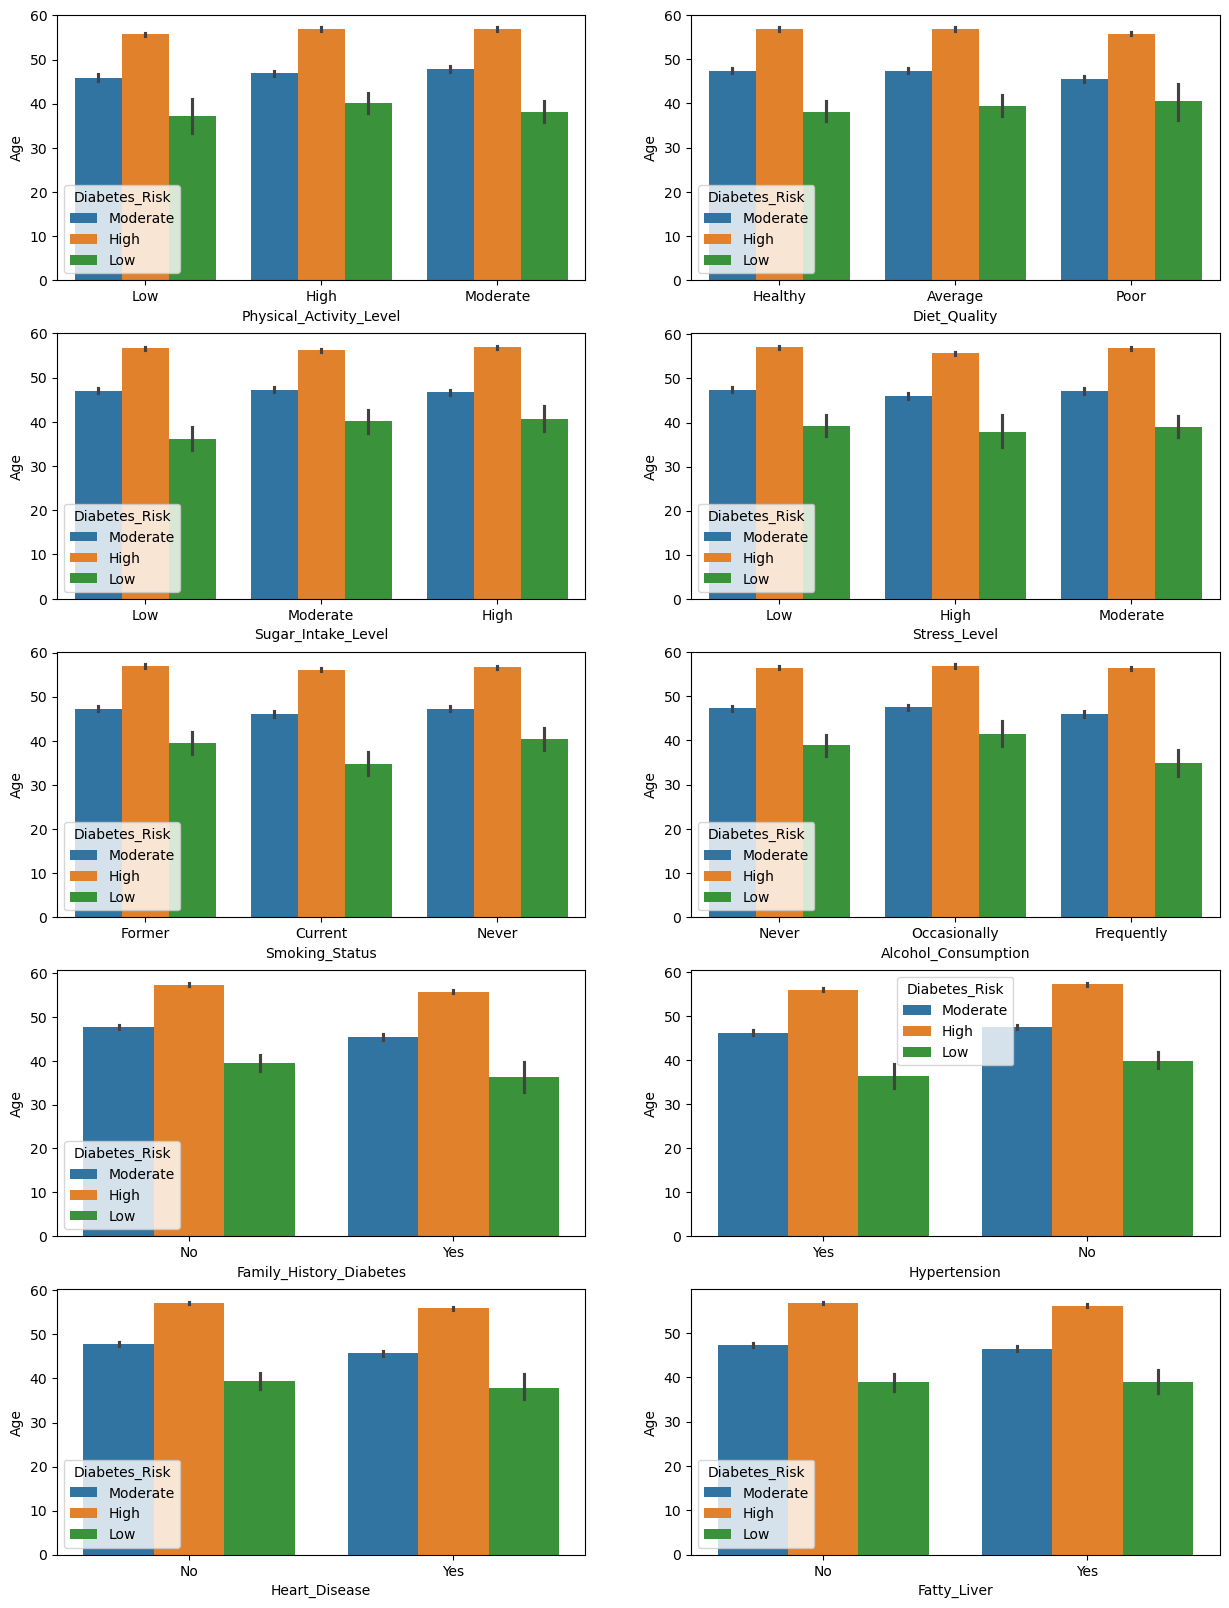

In [135]:
val = category_cols[2:12]


fig , ax  = plt.subplots( 5,2 , figsize = ( 15,20 ) )
ax = ax.flatten()

for idx , var in enumerate ( val ) : 
    order = df[var].value_counts().sort_values(ascending=False).index
    sns.barplot( data = df ,
                   x = var ,
                    y = 'Age',
                   hue = 'Diabetes_Risk',
                   order = order, 
                   ax = ax[idx]
                 )

There is no significant relationship and model cannot learn pattern on uniform distributions 